# Experiment 2: learning a 2D energy functional

The target functional combines a kinetic term with a density- and mediator-dependent local
stiffness $\varkappa_r[\alpha, \beta] \in (0, 2)$ and a screened Coulomb interaction:
$E_{\rm tot} = \frac{1}{2 N_x N_y}\sum_r \varkappa_r \left[(\partial_x\rho)^2 + (\partial_y\rho)^2\right] + \frac{1}{2 N_x N_y}\sum_{r,r'} \rho_r K_{q_s}(r-r') \rho_{r'}$.

| model | section | energy terms fed in | features | expectation |
|---|---|---|---|---|
| **EwaldNN** | 1 | bare kinetic only | local densities + learned mediator $\varphi = \mathcal{K} * \rho$ | succeeds for every $q_s$ |
| **LERN_SR** (SR = short range) | 2 | bare kinetic + unscreened Coulomb | local densities | succeeds for $\beta = 0$, $q_s = 0$; struggles otherwise |
| **LERN_LR** (LR = long range; DM21-like) | 3 | bare kinetic + unscreened Coulomb | + nonlocal unscreened Hartree energy | succeeds also for $\beta \neq 0$, $q_s = 0$; degrades for $q_s > 0$ |

Set `data_regime`, `alpha`, `beta`, `qs` below, then run top to bottom. With `flag_train = False`
the notebook loads the existing checkpoints (`LearningEngFunc2d_checkpoints/`) and regenerates
the training-history exports in `Results_2D/Experiment_2/`. Checkpoint file names keep the
historical prefixes (`LERN2d_EngFunc_` for LERN_SR, `LERN2d_mod_EngFunc_` for LERN_LR).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math, os
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ewaldnn2d import *

torch.random.manual_seed(1234) # for reproducibility

# Global settings
dtype = torch.float64
device = "cpu"
N_batch = 100
N_epochs = 10000
lr = 1e-1 # we will use a LR scheduler, so this is just an initial value
min_delta = 1e-5 # min change in the monitored quantity to qualify as an improvement
patience = 100    # epochs to wait for improvement before stopping training
N_pow = 1 # number of local features per grid point
N_train = 1500
N_test = 250
N_val = 250
ckpt_dir = "LearningEngFunc2d_checkpoints"
flag_train = False # if True, (re)train models; if False, use existing checkpoints

# grid and basis settings
N_x = 32 # number of grid points in x direction
N_y = N_x # number of grid points in y direction
m_x = torch.arange(0, N_x, dtype=dtype, device=device)             # (N_x,)
m_y = torch.arange(0, N_y, dtype=dtype, device=device)             # (N_y,)
abs_val = torch.sqrt(m_x[:, None]**2 + m_y[None, :]**2)  # (M_x, M_y)
x = torch.linspace(0, 1, N_x, dtype=dtype, device=device)            # (N_x,)
y = torch.linspace(0, 1, N_y, dtype=dtype, device=device)            # (N_y,)
DM_x = torch.cos(torch.pi * torch.outer(m_x, x))                  # (M_x, N_x)
DM_y = torch.cos(torch.pi * torch.outer(m_y, y))                  # (M_y, N_y)
DerDM_x = -torch.pi * m_x[:, None] * torch.sin(torch.pi * torch.outer(m_x, x))  # (M_x, N_x) # derivative of design matrix
DerDM_y = -torch.pi * m_y[:, None] * torch.sin(torch.pi * torch.outer(m_y, y))  # (M_y, N_y) # derivative of design matrix

data_regime = "smooth" # "smooth" or "rough"
if data_regime == "smooth":
    M_cutoff = 10 # maximum harmonic
    std_harm = 2.0 / (1.0 + 0.2 * abs_val)**2 * (abs_val <= M_cutoff).double()  # (M_x, M_y)
elif data_regime == "rough":
    std_harm = 2.0 / (1.0 + 0.0 * abs_val)**2 # (M_x, M_y)
else:
    raise ValueError("regime must be 'smooth' or 'rough'")
std_harm[0, 0] = 0.0 # no uniform density offset

# local stiffness parameters; chosen so that kappa spreads over (0, 2)
# without saturating the tanh (see the diagnostic histogram below). Scales of the
# tanh argument terms (smooth regime, 32x32): |4-neighbor product| ~ 8 (median),
# phi std ~ 975 / 515 / 50 for qs = 0 / 0.1 / 0.5
alpha = 0.005
beta = -0.002

# interaction kernel parameters
qs = 0.1 # screening momentum
amp = 1.0 # amplitude of interaction kernel
kernel_regime = "screened_coulomb"

# bare (kappa = 1) local kinetic energy density - fed to the models
def E_kin_loc(rho, d_rho_x, d_rho_y, eng_dens_flag=False):
    return E_kin_custom(rho, d_rho_x, d_rho_y, alpha=0.0, beta=0.0, qs=qs, eng_dens_flag=eng_dens_flag)

# unscreened Coulomb (Hartree) local energy density - fed to the models
def E_HF_loc(rho, d_rho_x, d_rho_y, eng_dens_flag=False):
    return amp * E_int_ms_dct(rho, kernel=kernel_regime, eng_dens_flag=eng_dens_flag, qs=0.0)

# target: kinetic term with stiffness kappa[alpha, beta] + screened interaction
def E_tot(rho, d_rho_x, d_rho_y):
    return E_kin_custom(rho, d_rho_x, d_rho_y, alpha=alpha, beta=beta, qs=qs) \
         + amp * E_int_ms_dct(rho, kernel=kernel_regime, qs=qs)

# generate train/test split (all three models share this dataset)
fname = f"DATA2d/EngFunc_dataset_{data_regime}_{kernel_regime}_{alpha}_{beta}_{qs}_{amp}_{N_x}_{N_y}.pt"
flag_generate_data = not os.path.isfile(fname) # generate once; set to True to force regeneration
if flag_generate_data:
    N_batch_int = 10 # number of density profiles per data generation batch
    torch.manual_seed(1234) # for reproducibility
    rho_train, d_rho_x_train, d_rho_y_train, a_train, E_loc_kin_train, E_loc_HF_train, E_tot_train = generate_EngFunc_data_2d(N_train, N_batch_int, E_kin_loc, E_HF_loc, E_tot, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_test, d_rho_x_test, d_rho_y_test, a_test, E_loc_kin_test, E_loc_HF_test, E_tot_test = generate_EngFunc_data_2d(N_test, N_batch_int, E_kin_loc, E_HF_loc, E_tot, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    rho_val, d_rho_x_val, d_rho_y_val, a_val, E_loc_kin_val, E_loc_HF_val, E_tot_val = generate_EngFunc_data_2d(N_val, N_batch_int, E_kin_loc, E_HF_loc, E_tot, std_harm=std_harm, DM_x=DM_x, DerDM_x=DerDM_x, DM_y=DM_y, DerDM_y=DerDM_y)
    os.makedirs("DATA2d", exist_ok=True)
    torch.save(
        {
            "rho_train": rho_train, "d_rho_x_train": d_rho_x_train, "d_rho_y_train": d_rho_y_train, "a_train": a_train,
            "E_loc_kin_train": E_loc_kin_train, "E_loc_HF_train": E_loc_HF_train, "E_tot_train": E_tot_train,
            "rho_val": rho_val, "d_rho_x_val": d_rho_x_val, "d_rho_y_val": d_rho_y_val, "a_val": a_val,
            "E_loc_kin_val": E_loc_kin_val, "E_loc_HF_val": E_loc_HF_val, "E_tot_val": E_tot_val,
            "rho_test": rho_test, "d_rho_x_test": d_rho_x_test, "d_rho_y_test": d_rho_y_test, "a_test": a_test,
            "E_loc_kin_test": E_loc_kin_test, "E_loc_HF_test": E_loc_HF_test, "E_tot_test": E_tot_test,
            "data_regime": data_regime, "kernel_regime": kernel_regime, "alpha": alpha, "beta": beta, "qs": qs, "amp": amp,
        },
        fname,
    )
else:
    data = torch.load(fname)
    rho_train, E_loc_kin_train, E_loc_HF_train, E_tot_train = data["rho_train"], data["E_loc_kin_train"], data["E_loc_HF_train"], data["E_tot_train"]
    rho_test, E_loc_kin_test, E_loc_HF_test, E_tot_test = data["rho_test"], data["E_loc_kin_test"], data["E_loc_HF_test"], data["E_tot_test"]
    rho_val, E_loc_kin_val, E_loc_HF_val, E_tot_val = data["rho_val"], data["E_loc_kin_val"], data["E_loc_HF_val"], data["E_tot_val"]

# Normalize targets (shared by all three models)
E_mean = E_tot_train.mean()
E_std = E_tot_train.std()

n_hidden_list = [1, 2, 3, 4]
n_neurons_list = [8, 16, 32, 64]
os.makedirs("Results_2D/Experiment_2", exist_ok=True)


def build_features(rho, E_loc_HF, R_feat, add_HF, energy_terms, stats=None):
    """Local features (densities of the site and its neighbours within R_feat), for LERN_LR
    additionally the nonlocal unscreened Hartree energy as a feature (appended before
    normalization); the raw energy terms to be reweighted are appended last.
    Returns (packed features, normalization stats, N_feat)."""
    f = extend_features_neighbors_2d(generate_loc_features_rs(rho, N_pow=N_pow), R=R_feat)
    if add_HF:
        f = torch.cat([f, E_loc_HF], dim=-1)
    if stats is None:
        stats = compute_normalization_stats(f)
    return torch.cat([normalize_features(f, *stats), *energy_terms], dim=-1), stats, f.shape[-1]


def make_loaders(f_train, f_val):
    train_loader = DataLoader(TensorDataset(f_train, (E_tot_train - E_mean) / E_std), batch_size=N_batch, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(TensorDataset(f_val,   (E_tot_val - E_mean) / E_std),   batch_size=N_batch, shuffle=False, drop_last=False)
    return train_loader, val_loader


def run_name_for(prefix, N_feat, N_energy_terms, n_hidden, n_neurons, seed):
    return f"{prefix}" + data_regime + '_' + kernel_regime + f"_{alpha}_{beta}_{qs}_{amp}_{N_x}_{N_y}_{N_feat}_{N_energy_terms}_{n_hidden}_{n_neurons}_{seed}"


def train_grid(prefix, model_class, learning_regime, N_energy_terms, train_loader, val_loader, N_feat, mean_feat, std_feat):
    """Hyperparameter grid search: 4 depths x 4 widths x 3 seeds (N_feat is set by R_feat
    in the feature-building cell; run with both R_feat values to cover the full grid)."""
    for n_hidden in n_hidden_list:
        for n_neurons in n_neurons_list:
            for seed in range(3):
                torch.manual_seed(1234 + seed)
                run_name = run_name_for(prefix, N_feat, N_energy_terms, n_hidden, n_neurons, seed)
                print(f"Training model: n_hidden={n_hidden}, n_neurons={n_neurons}, seed={seed}")
                model = model_class(
                        N_x=N_x, N_y=N_y, N_energy_terms=N_energy_terms, N_feat=N_feat,
                        n_hidden=n_hidden, n_neurons=n_neurons,
                        mean_feat=mean_feat, std_feat=std_feat, E_mean=E_mean, E_std=E_std,
                    ).to(device=device, dtype=dtype)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=50, cooldown=2, min_lr=1e-6)
                train_with_early_stopping(
                    model=model, train_loader=train_loader, val_loader=val_loader,
                    criterion=nn.MSELoss(), optimizer=optimizer, scheduler=scheduler,
                    max_epochs=N_epochs, patience=patience, min_delta=min_delta,
                    ckpt_dir=ckpt_dir, run_name=run_name, learning_regime=learning_regime,
                    N_x=N_x, N_y=N_y, device=device)


def select_best(prefix, model_class, N_feat_list, N_energy_terms):
    """Best checkpoint over the full grid (depth x width x seed x feature set)."""
    best_val, best_run, best_N_feat = math.inf, None, None
    for n_hidden in n_hidden_list:
        for n_neurons in n_neurons_list:
            for seed in range(3):
                for N_feat in N_feat_list:
                    run_name = run_name_for(prefix, N_feat, N_energy_terms, n_hidden, n_neurons, seed)
                    _, _, _, val_loss = load_checkpoint(ckpt_dir + f"/{run_name}_best.pt", model_class, device=device)
                    if val_loss < best_val:
                        best_val, best_run, best_N_feat = val_loss, run_name, N_feat
    print(f"Overall best model: {best_run}  (val_loss={best_val:.10f})")
    return best_run, best_N_feat


def plot_history_and_export(run_name, out_file):
    hist_df = pd.read_csv(ckpt_dir + f"/{run_name}_history.csv")
    hist_df.plot(x="epoch", y=["train_loss", "val_loss"], logy=True, grid=True, title=run_name)
    data = np.column_stack([hist_df["epoch"].to_numpy(), hist_df["train_loss"].to_numpy(), hist_df["val_loss"].to_numpy()])
    np.savetxt(out_file, data)
    print(f"Best validation loss: {min(data[:, 2])}  ->  {out_file}")


def show_lern_factors(run_name, N_feat_best, add_HF, k=0):
    """Reload the best LERN_SR / LERN_LR checkpoint, rebuild matching test features
    (N_feat fixes R_feat; stats come from the checkpoint) and show the true stiffness,
    the learned factors f_kin, f_int for test sample k, and their pooled histograms.
    If learning succeeded, f_kin should track kappa; for qs = 0 the exact solution is
    f_kin = kappa and f_int = 1."""
    model, normalization, _, _ = load_checkpoint(ckpt_dir + f"/{run_name}_best.pt", LERN2d, device=device)
    model = model.to(device=device, dtype=dtype)
    R_feat_best = 1.0 if N_feat_best == (6 if add_HF else 5) else 1.5
    f_norm, _, _ = build_features(rho_test, E_loc_HF_test, R_feat_best, add_HF, [],
                                  (normalization["mean_feat"], normalization["std_feat"]))
    with torch.no_grad():
        factors = model.local_nn(f_norm)                      # (N_test, N_x, N_y, 2): [f_kin, f_int]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    maps = [
        (kappa_test[k].numpy().T, r"true $\varkappa(x,y)$"),
        (factors[k, :, :, 0].numpy().T, r"$f_{\rm kin}(x,y)$"),
        (factors[k, :, :, 1].numpy().T, r"$f_{\rm int}(x,y)$"),
    ]
    for ax, (arr, title) in zip(axes, maps):
        im = ax.imshow(arr, origin="lower", extent=[0, 1, 0, 1], aspect="equal", vmin=0.0, vmax=2.0)
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

    bins = np.linspace(0.0, 2.0, 101)
    plt.figure(figsize=(5, 4))
    plt.hist(kappa_test.reshape(-1).numpy(), bins=bins, density=True, alpha=0.5, label=r"true $\varkappa$")
    plt.hist(factors[..., 0].reshape(-1).numpy(), bins=bins, density=True, alpha=0.5, label=r"$f_{\rm kin}$")
    plt.hist(factors[..., 1].reshape(-1).numpy(), bins=bins, density=True, alpha=0.5, label=r"$f_{\rm int}$")
    plt.xlim(-0.1, 2.1)
    plt.xlabel("local factor value")
    plt.ylabel("probability density")
    plt.legend()
    plt.title(f"Learned local factors vs true stiffness\n"
              rf"(pooled over {N_test} samples and space)")
    plt.tight_layout()
    plt.show()
    return model

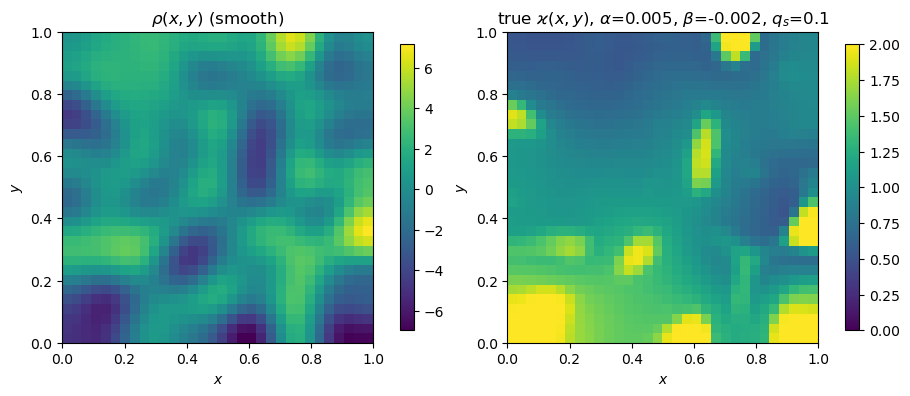

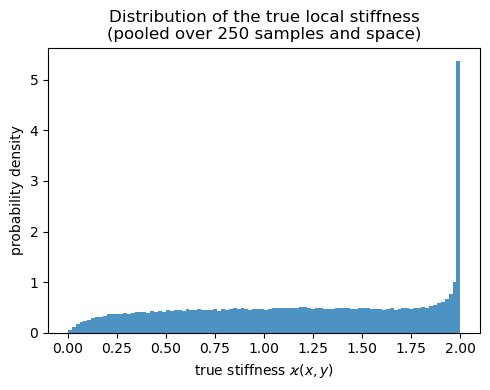

In [2]:
# visualize a sampled density profile and the true local stiffness kappa_r
k = 0  # index of the test sample to visualize
kappa_test = kappa_custom(rho_test, alpha=alpha, beta=beta, qs=qs)  # (N_test, N_x, N_y)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
im0 = axes[0].imshow(
    rho_test[k].numpy().T,              # transpose so x is horizontal, y vertical
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal"
)
axes[0].set_title(rf"$\rho(x,y)$ ({data_regime})")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(
    kappa_test[k].numpy().T,
    origin="lower",
    extent=[0, 1, 0, 1],
    aspect="equal",
    vmin=0.0, vmax=2.0
)
axes[1].set_title(rf"true $\varkappa(x,y)$, $\alpha$={alpha}, $\beta$={beta}, $q_s$={qs}")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.show()

# pooled distribution of the true stiffness - a diagnostic for choosing alpha and beta:
# kappa should neither saturate at {0, 2} nor collapse onto 1
plt.figure(figsize=(5, 4))
plt.hist(kappa_test.reshape(-1).numpy(), bins=np.linspace(0.0, 2.0, 101), density=True, alpha=0.8)
plt.xlabel(r"true stiffness $\varkappa(x,y)$")
plt.ylabel("probability density")
plt.title(f"Distribution of the true local stiffness\n"
          rf"(pooled over {N_test} samples and space)")
plt.tight_layout()
plt.show()

## 1) EwaldNN

Only the bare ($\varkappa = 1$) local kinetic energy density is fed in. The model learns the mediator
field $\varphi = \mathcal{K} * \rho$ (screened Coulomb with learnable amplitude and screening momentum),
which enters both the feature vector - so the stiffness $\varkappa(\mathbf{x}, \varphi)$ is
representable - and the explicit pairwise energy $\frac{1}{2}\varphi\rho$, which captures the screened
interaction. Expected to succeed for every $q_s \in \{0, 0.1, 0.5\}$.

In [3]:
# EwaldNN features and loaders: bare kinetic energy is the single reweighted term
R_feat = 1.0 # radius for neighbor feature extension: 1.0 (4 neighbors) or 1.5 (8 neighbors)
features_train_norm, stats, N_feat = build_features(rho_train, E_loc_HF_train, R_feat, add_HF=False, energy_terms=[E_loc_kin_train])
features_val_norm, _, _ = build_features(rho_val, E_loc_HF_val, R_feat, add_HF=False, energy_terms=[E_loc_kin_val], stats=stats)
mean_feat, std_feat = stats
print(f"Number of local features per grid point: {N_feat}")

train_loader, val_loader = make_loaders(features_train_norm, features_val_norm)

if flag_train:
    train_grid("EwaldNN2d_EngFunc_", EwaldNN2d, "EwaldNN2d", 1, train_loader, val_loader, N_feat, mean_feat, std_feat)

Number of local features per grid point: 5


Overall best model: EwaldNN2d_EngFunc_smooth_screened_coulomb_0.005_-0.002_0.1_1.0_32_32_9_1_2_8_1  (val_loss=0.0000275997)
Best validation loss: 2.7599696768895125e-05  ->  Results_2D/Experiment_2/EwaldNN_performance_smooth_0.005_-0.002_0.1.txt


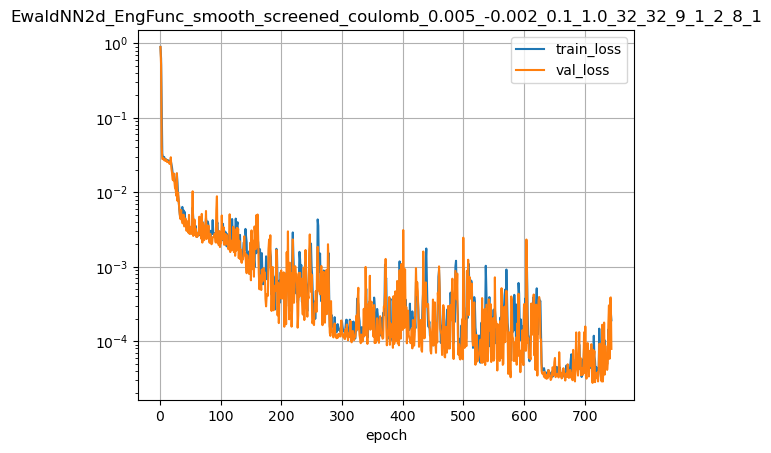

In [4]:
run_name_Ewald, N_feat_Ewald = select_best("EwaldNN2d_EngFunc_", EwaldNN2d, N_feat_list=[5, 9], N_energy_terms=1)
plot_history_and_export(run_name_Ewald, f"Results_2D/Experiment_2/EwaldNN_performance_{data_regime}_{alpha}_{beta}_{qs}.txt")

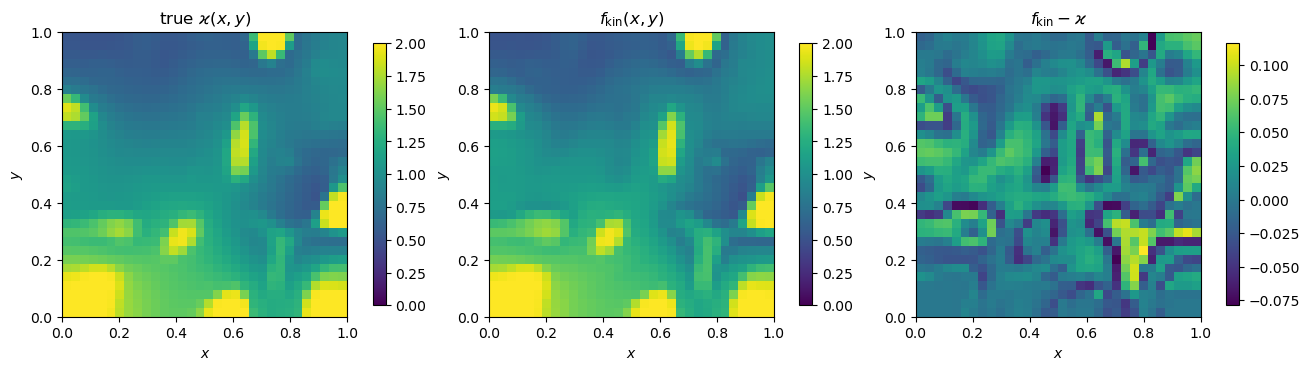

In [5]:
model, normalization, epoch, val_loss = load_checkpoint(
        ckpt_dir + f"/{run_name_Ewald}_best.pt",
        EwaldNN2d,
        device=device
    )
model = model.to(device=device, dtype=dtype)

# Rebuild the test features to match the best model's feature set:
# N_feat = 5 -> R_feat = 1.0 (4 nearest neighbors), N_feat = 9 -> R_feat = 1.5 (8 neighbors).
# Normalization stats come from the checkpoint, as they were computed for that feature set.
R_feat_best = 1.0 if N_feat_Ewald == 5 else 1.5
features_test_best_norm, _, _ = build_features(rho_test, E_loc_HF_test, R_feat_best, add_HF=False, energy_terms=[],
                                               stats=(normalization["mean_feat"], normalization["std_feat"]))

def ewald_factors(model, features_norm, rho):
    """Reweighting factors of EwaldNN2d: local_nn on [features, mediator feature]."""
    with torch.no_grad():
        _, phi_feat = model.mediator.phi_and_feature(rho)
        phi_feat = phi_feat / model.std_feat[..., 0]
        return model.local_nn(torch.cat([features_norm, phi_feat.unsqueeze(-1)], dim=-1))

k = 0  # index of the test sample to visualize
factors = ewald_factors(model, features_test_best_norm[k:k+1], rho_test[k:k+1])  # (1, N_x, N_y, 1)

# the exact solution (for any qs) is f_kin = kappa, with the interaction
# absorbed by the mediator energy term (1/2) phi rho
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
f_kin = factors[0, :, :, 0].numpy()
maps = [
    (kappa_test[k].numpy().T, r"true $\varkappa(x,y)$", 0.0, 2.0),
    (f_kin.T, r"$f_{\rm kin}(x,y)$", 0.0, 2.0),
    ((f_kin - kappa_test[k].numpy()).T, r"$f_{\rm kin} - \varkappa$", None, None),
]
for ax, (arr, title, vmin, vmax) in zip(axes, maps):
    im = ax.imshow(arr, origin="lower", extent=[0, 1, 0, 1], aspect="equal", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

Learned mediator: amp = 0.997723 (true 1.0), qs = 0.099664 (true 0.1)


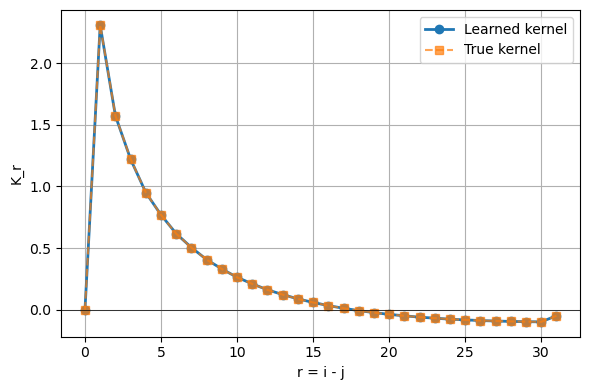

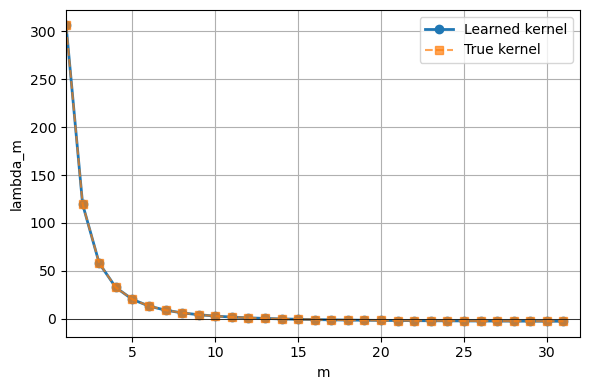

In [6]:
# learned mediator vs the true screened Coulomb interaction kernel
with torch.no_grad():
    amp_learned = model.mediator.amp
    qs_learned = F.softplus(model.mediator.raw_qs)
print(f"Learned mediator: amp = {amp_learned.item():.6f} (true {amp}), qs = {qs_learned.item():.6f} (true {qs})")

m_vals = torch.arange(0, N_x, device=device, dtype=dtype)
n_vals = torch.arange(0, N_y, device=device, dtype=dtype)
q_x = torch.pi * m_vals.view(-1, 1) / (N_x - 1)
q_y = torch.pi * n_vals.view(1, -1) / (N_y - 1)
q_vals = torch.sqrt(q_x**2 + q_y**2)  # (N_x, N_y)

with torch.no_grad():
    lam_K_learned = amp_learned * Lam_K_Coulomb(q_vals.clone(), qs=qs_learned)
lam_K_true = amp * Lam_K_Coulomb(q_vals.clone(), qs=qs)
k_learned = kernel_from_eigenvals_dct(lam_K_learned)
k_true = kernel_from_eigenvals_dct(lam_K_true)

r_grid = np.arange(0, N_x)
plt.figure(figsize=(6, 4))
plt.plot(r_grid, k_learned[:, 0].numpy(), 'o-', label='Learned kernel', linewidth=2)
plt.plot(r_grid, k_true[:, 0].numpy(), 's--', label='True kernel', alpha=0.7)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("r = i - j")
plt.ylabel("K_r")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(r_grid, lam_K_learned[:, 0].numpy(), 'o-', label='Learned kernel', linewidth=2)
plt.plot(r_grid, lam_K_true[:, 0].numpy(), 's--', label='True kernel', alpha=0.7)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("m")
plt.ylabel("lambda_m")
plt.xlim(1, N_x)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

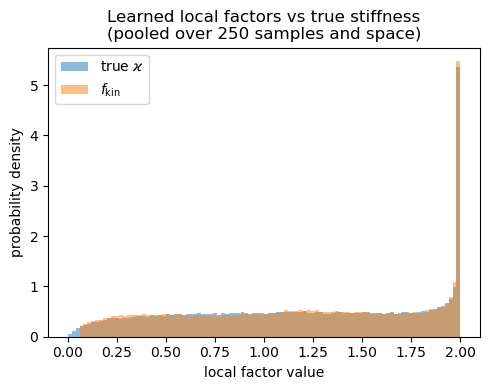

In [7]:
f_kin_all = []
for k in range(N_test):
    factors = ewald_factors(model, features_test_best_norm[k:k+1], rho_test[k:k+1])  # (1, N_x, N_y, 1)
    f_kin_all.append(factors[..., 0].reshape(-1).numpy())
f_kin_all = np.concatenate(f_kin_all)

bins = np.linspace(0.0, 2.0, 101)
plt.figure(figsize=(5, 4))
plt.hist(kappa_test.reshape(-1).numpy(), bins=bins, density=True, alpha=0.5, label=r"true $\varkappa$")
plt.hist(f_kin_all, bins=bins, density=True, alpha=0.5, label=r"$f_{\rm kin}$")
plt.xlim(-0.1, 2.1)
plt.xlabel("local factor value")
plt.ylabel("probability density")
plt.legend()
plt.title(f"Learned local factors vs true stiffness\n"
          rf"(pooled over {N_test} samples and space)")
plt.tight_layout()
plt.show()

## 2) LERN_SR: local reweighting with short-range features

The model is fed two local energy terms - the bare ($\varkappa = 1$) kinetic energy density and the
unscreened local Coulomb energy - and reweights them with local factors $f_{\rm kin}, f_{\rm int} \in [0, 2]$;
the feature vector is the same as in Experiment 1 (local densities). Expected: succeeds for
$\beta = 0$, $q_s = 0$; struggles once $\beta \neq 0$ or $q_s > 0$ (nonlocal physics enters).

In [8]:
# LERN_SR features and loaders (checkpoint prefix "LERN2d_EngFunc_" predates the renaming)
R_feat = 1.0 # radius for neighbor feature extension: 1.0 (4 neighbors) or 1.5 (8 neighbors)
features_train_norm, stats, N_feat = build_features(rho_train, E_loc_HF_train, R_feat, add_HF=False, energy_terms=[E_loc_kin_train, E_loc_HF_train])
features_val_norm, _, _ = build_features(rho_val, E_loc_HF_val, R_feat, add_HF=False, energy_terms=[E_loc_kin_val, E_loc_HF_val], stats=stats)
mean_feat, std_feat = stats
print(f"Number of local features per grid point: {N_feat}")

train_loader, val_loader = make_loaders(features_train_norm, features_val_norm)

if flag_train:
    train_grid("LERN2d_EngFunc_", LERN2d, "LERN2d", 2, train_loader, val_loader, N_feat, mean_feat, std_feat)

Number of local features per grid point: 5


Overall best model: LERN2d_EngFunc_smooth_screened_coulomb_0.005_-0.002_0.1_1.0_32_32_9_2_2_16_0  (val_loss=0.0039540390)
Best validation loss: 0.0039540390380344  ->  Results_2D/Experiment_2/LERN_SR_performance_smooth_0.005_-0.002_0.1.txt


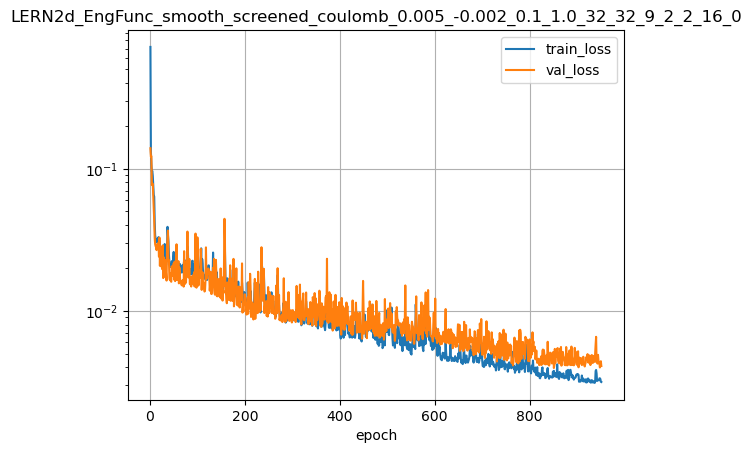

In [9]:
run_name_SR, N_feat_SR = select_best("LERN2d_EngFunc_", LERN2d, N_feat_list=[5, 9], N_energy_terms=2)
plot_history_and_export(run_name_SR, f"Results_2D/Experiment_2/LERN_SR_performance_{data_regime}_{alpha}_{beta}_{qs}.txt")

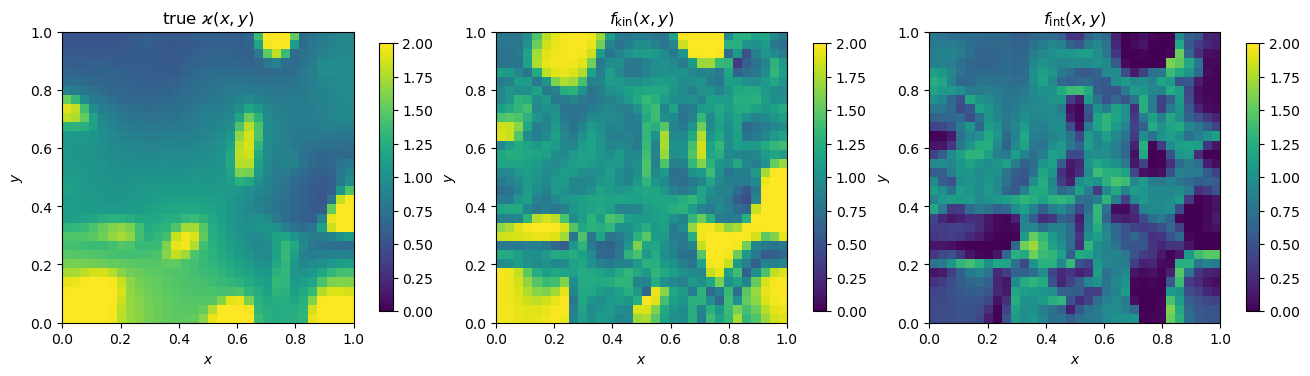

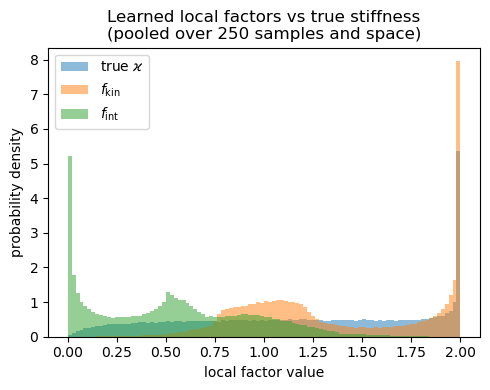

In [10]:
model_SR = show_lern_factors(run_name_SR, N_feat_SR, add_HF=False)

## 3) LERN_LR: local reweighting with a long-range feature (DM21-like)

Identical to the LERN_SR setup (two reweighted energy terms: bare kinetic + unscreened Coulomb),
except the feature vector additionally contains the nonlocal unscreened Hartree energy density -
the DM21-like architectural change. Expected: succeeds also for $\beta \neq 0$, $q_s = 0$;
degrades for $q_s > 0$.

In [11]:
# LERN_LR features and loaders (checkpoint prefix "LERN2d_mod_EngFunc_" predates the renaming)
R_feat = 1.0 # radius for neighbor feature extension: 1.0 (4 neighbors) or 1.5 (8 neighbors)
features_train_norm, stats, N_feat = build_features(rho_train, E_loc_HF_train, R_feat, add_HF=True, energy_terms=[E_loc_kin_train, E_loc_HF_train])
features_val_norm, _, _ = build_features(rho_val, E_loc_HF_val, R_feat, add_HF=True, energy_terms=[E_loc_kin_val, E_loc_HF_val], stats=stats)
mean_feat, std_feat = stats
print(f"Number of local features per grid point: {N_feat}")

train_loader, val_loader = make_loaders(features_train_norm, features_val_norm)

if flag_train:
    train_grid("LERN2d_mod_EngFunc_", LERN2d, "LERN2d", 2, train_loader, val_loader, N_feat, mean_feat, std_feat)

Number of local features per grid point: 6


Overall best model: LERN2d_mod_EngFunc_smooth_screened_coulomb_0.005_-0.002_0.1_1.0_32_32_10_2_2_32_1  (val_loss=0.0003947376)
Best validation loss: 0.0003947376265251  ->  Results_2D/Experiment_2/LERN_LR_performance_smooth_0.005_-0.002_0.1.txt


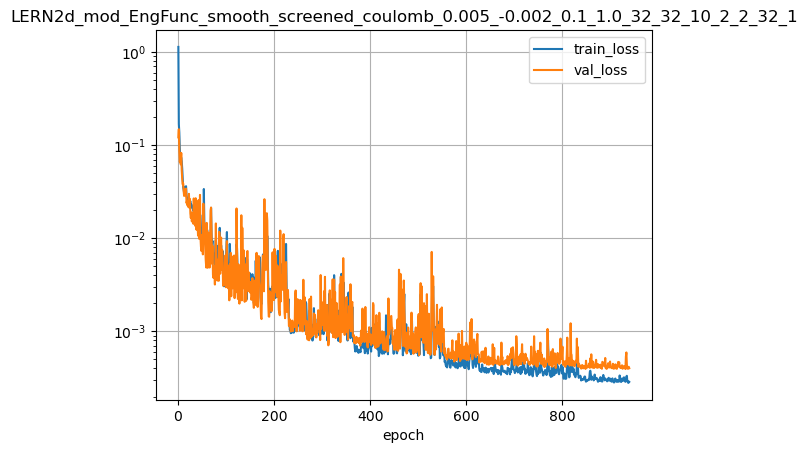

In [12]:
run_name_LR, N_feat_LR = select_best("LERN2d_mod_EngFunc_", LERN2d, N_feat_list=[6, 10], N_energy_terms=2)
plot_history_and_export(run_name_LR, f"Results_2D/Experiment_2/LERN_LR_performance_{data_regime}_{alpha}_{beta}_{qs}.txt")

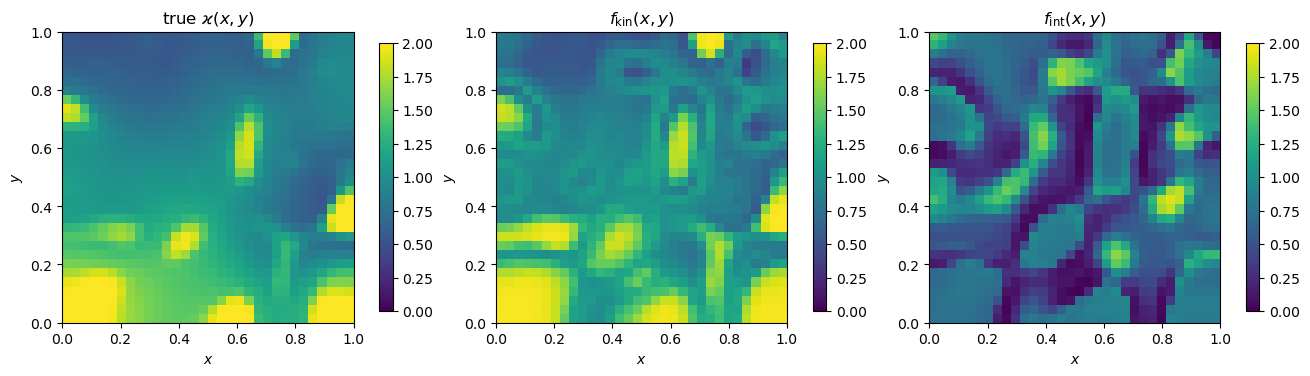

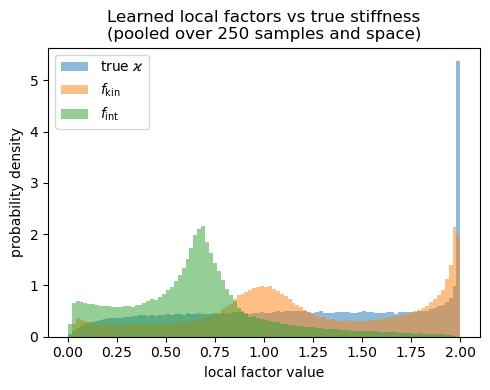

In [13]:
model_LR = show_lern_factors(run_name_LR, N_feat_LR, add_HF=True)